# Resumen


### Variables Estáticas Débiles
Las características intrínsecas (capacidad, reseñas, tipo) son insuficientes por sí solas; la ocupación no es una foto fija, sino un **proceso dinámico**.

### Mercado Estrictamente No Lineal
La convergencia de Kruskal-Wallis, LOWESS y MI confirma que las reglas del mercado son complejas. Los modelos lineales son descartados en favor de algoritmos de **Gradient Boosting (árboles)**.

### La Memoria Temporal
La historia reciente dicta el futuro. El rezago semanal (Lag 7) de la temperatura y la evolución del precio (Lags 1-2) capturan la inercia del mercado. El sistema responde a **ritmos semanales, no a eventos aislados.**

### El Barrio como Modificador de Reglas
Aunque no hay un contagio espacial directo (Moran Global neutro), el **barrio define la elasticidad del mercado.** La estructura de precios se fragmenta geográficamente, especialmente en verano, cuando cada zona activa sus propias reglas de oferta y demanda.

# 0. Conexión con proyecto e importación de dataset

In [1]:
%load_ext autoreload
%autoreload 2

from spatial_temporal import *

warnings.filterwarnings("ignore", module="statsmodels.tsa.stattools")
warnings.filterwarnings('ignore')

In [2]:
df = gpd.read_parquet(r"D:\yannis_data\Descargas\airbnb_bcn_clean.parquet")
df_barrios = pd.read_csv(r"D:\yannis_data\Descargas\BarcelonaCiutat_Barris.csv")

In [3]:
# 1. Crear el GeoDataFrame manteniendo EPSG:4326 
distritos_gdf = gpd.GeoDataFrame(
    df_barrios, 
    geometry=gpd.points_from_xy(df_barrios.longitude, df_barrios.latitude) if 'lat' in df_barrios else df_barrios['geometria_wgs84'].apply(wkt.loads),
    crs="EPSG:4326")

# 2. Asegurar de que la columna se llame 'geometry' y sea la activa
distritos_gdf = distritos_gdf.set_geometry('geometry')

# 3. Normalizar usando el mismo nombre que espera tu función 
distritos_gdf['key_spatial'] = distritos_gdf['nom_barri'].str.lower().str.strip()

# 4. Agrupar puntos
conteo_barrios = df.groupby('neighbourhood_cleansed').size().reset_index(name='count')
conteo_barrios['key_spatial'] = conteo_barrios['neighbourhood_cleansed'].str.lower().str.strip()

# 5. Merge 
gdf_mapa = distritos_gdf.merge(conteo_barrios, on='key_spatial', how='inner')

In [4]:
# 1. Convertir la columna de texto WKT a objetos geométricos reales
if not isinstance(df_barrios['geometria_wgs84'].iloc[0], (str, bytes)) == False:
    geometrias = df_barrios['geometria_wgs84'].apply(wkt.loads)
else:
    geometrias = df_barrios['geometria_wgs84']

# 2. CREAR EL GEODATAFRAME (Esto es lo que falta para que tenga .crs)
df_barrios = gpd.GeoDataFrame(df_barrios, geometry=geometrias, crs="EPSG:4326")

# 3. Asegurarnos de que la columna se llame 'geometry'
df_barrios = df_barrios.set_geometry('geometry')

df_barrios = df_barrios.drop(columns=['geometria_etrs89', 'geometria_wgs84'], errors='ignore')


☀️ DINÁMICA ESTACIONAL: VERANO vs RESTO DEL AÑO


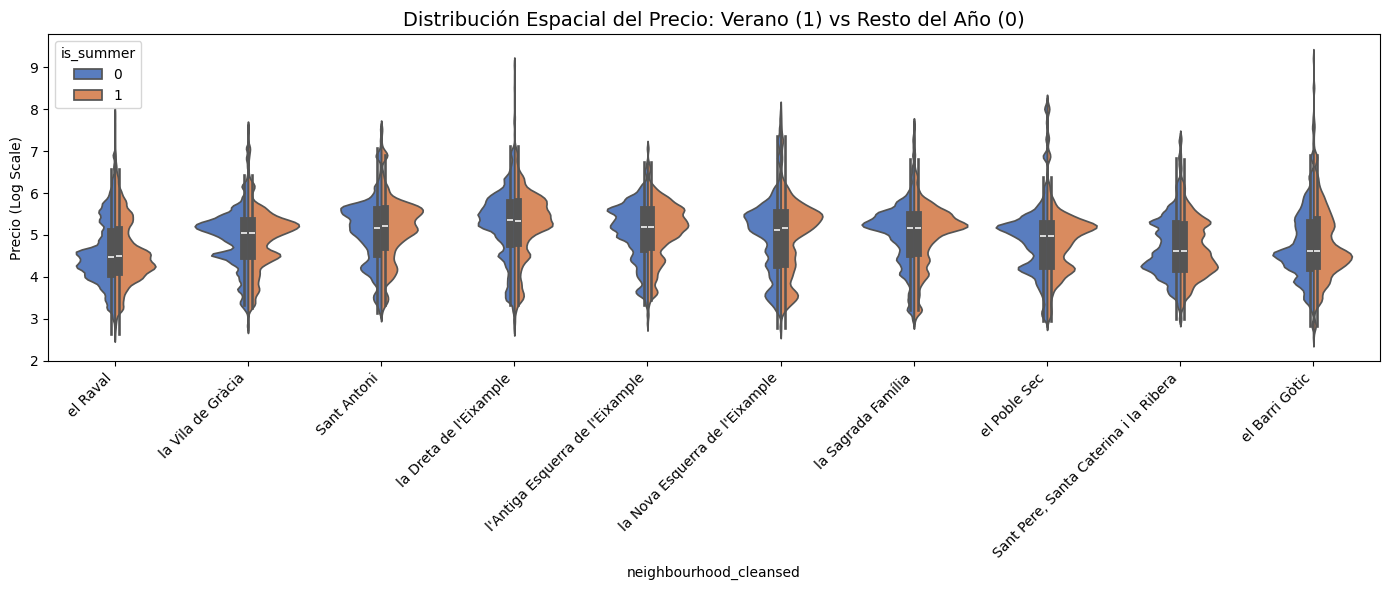


⏳🗺️ INGENIERÍA DE VARIABLES: REZAGOS ESPACIO-TEMPORALES
[+] Ejemplo de rezagos espacio-temporales generados:
   neighbourhood_cleansed       date  is_occupied  tasa_barrio_7d_pasados
1                Can Baró 2025-06-24          0.5                1.000000
2                Can Baró 2025-06-25     0.583333                0.750000
3                Can Baró 2025-06-26          0.5                0.694444
4                Can Baró 2025-06-27     0.416667                0.645833
5                Can Baró 2025-06-28     0.333333                0.600000
6                Can Baró 2025-06-29         0.25                0.555556
7                Can Baró 2025-06-30     0.166667                0.511905
8                Can Baró 2025-07-01     0.416667                0.392857
9                Can Baró 2025-07-02          0.5                0.380952
10               Can Baró 2025-07-03          0.5                0.369048

[!] Estas variables (tasa_barrio_7d_pasados) son ORO puro para tu modelo XG

In [5]:
# 1. Validar el comportamiento anómalo del verano en el espacio
analyze_seasonal_spatial_clusters(df, target='is_occupied', price_col='listing_price')

# 2. Generar las variables espacio-temporales para el modelo final
df_st_features = compute_spatiotemporal_lags(df, target='is_occupied')